In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/karkavelrajaj/amazon-sales-dataset/amazon.csv


# Amazon Products EDA Project

This project analyzes Amazon product ratings, prices, discounts, and reviews to extract insights using Python.

In [2]:
# importing libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# loading dataset
df = pd.read_csv("/kaggle/input/datasets/karkavelrajaj/amazon-sales-dataset/amazon.csv")

In [4]:
# Basic information about dataset
print("Info of dataset")
df.info()

print("\nShape of the dataset")
print(df.shape)

print("\nStatical info")
df.describe()

Info of dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   ob

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B08HDJ86NZ,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Borosil-Jumbo-1000-Watt-...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [5]:
# Checking for missing values per column
print(df.isnull().sum())

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64


# Data cleaning

In [6]:
df.head(10)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...
5,B08Y1TFSP6,pTron Solero TB301 3A Type-C Data and Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹149,"₹1,000",85%,3.9,"24,871",Fast Charging & Data Sync: Solero TB301 Type-C...,"AEQ2YMXSZWEOHK2EHTNLOS56YTZQ,AGRVINWECNY7323CW...","Jayesh,Rajesh k.,Soopy,amazon customer,Aman,Sh...","R7S8ANNSDPR40,R3CLZFLHVJU26P,RFF7U7MPQFUGR,R1M...","It's pretty good,Average quality,very good and...","It's a good product.,Like,Very good item stron...",https://m.media-amazon.com/images/I/31wOPjcSxl...,https://www.amazon.in/Solero-TB301-Charging-48...
6,B08WRWPM22,"boAt Micro USB 55 Tangle-free, Sturdy Micro US...",Computers&Accessories|Accessories&Peripherals|...,₹176.63,₹499,65%,4.1,"15,188",It Ensures High Speed Transmission And Chargin...,"AG7C6DAADCTRQJG2BRS3RIKDT52Q,AFU7BOMPVJ7Q3TTA4...","Vivek kumar,Amazon Customer,SARTHAK,Chiranjeev...","R8E73K2KWJRDS,RSD0JTIIWQQL8,R64CRSTE9SLW1,R2FR...","Long durable.,good,Does not charge Lenovo m8 t...",Build quality is good and it is comes with 2 y...,https://m.media-amazon.com/images/W/WEBP_4

In [7]:
# removing unneccessary symbols from price colmns
df['discounted_price'] = df['discounted_price'].str.replace('₹','').str.replace(',','')
df['actual_price'] = df['actual_price'].str.replace('₹','').str.replace(',','')

df['discounted_price'] = df['discounted_price'].astype(float)
df['actual_price'] = df['actual_price'].astype(float)

df['discount_percentage'] = df['discount_percentage'].str.replace('%','').astype(float)

df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [8]:
# top related products
df[['product_name','rating']].sort_values(by='rating', ascending=False).head(10)

,product_name,rating
174,Syncwire LTG to USB Cable for Fast Charging Co...,5.0
324,"REDTECH USB-C to Lightning Cable 3.3FT, [Apple...",5.0
775,Amazon Basics Wireless Mouse | 2.4 GHz Connect...,5.0
1145,Swiffer Instant Electric Water Heater Faucet T...,4.8
1201,"Oratech Coffee Frother electric, milk frother ...",4.8
1299,"Instant Pot Air Fryer, Vortex 2QT, Touch Contr...",4.8
1388,Campfire Spring Chef Prolix Instant Portable W...,4.7
1223,"FIGMENT Handheld Milk Frother Rechargeable, 3-...",4.7
1226,Zuvexa USB Rechargeable Electric Foam Maker - ...,4.7
1275,Multifunctional 2 in 1 Electric Egg Boiling St...,4.7


In [9]:
# most discounted produts
df[['product_name','discount_percentage']].sort_values(by='discount_percentage', ascending=False).head(10)

,product_name,discount_percentage
695,"rts [2 Pack] Mini USB C Type C Adapter Plug, T...",94.0
364,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
372,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
368,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
380,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
334,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",91.0
1026,beatXP Kitchen Scale Multipurpose Portable Ele...,90.0
557,LAPSTER 12pcs Spiral Cable Protectors for Char...,90.0
542,Sounce Protective Case Cover Compatible Boat X...,90.0
644,Sounce Spiral Charger Cable Protector Data Cab...,90.0


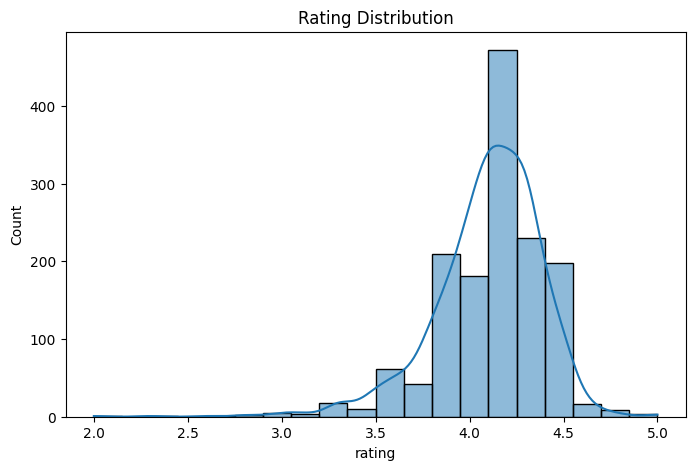

In [10]:
# rating distribution
plt.figure(figsize=(8,5))
sns.histplot(df['rating'], bins=20, kde=True)
plt.title("Rating Distribution")
plt.show()

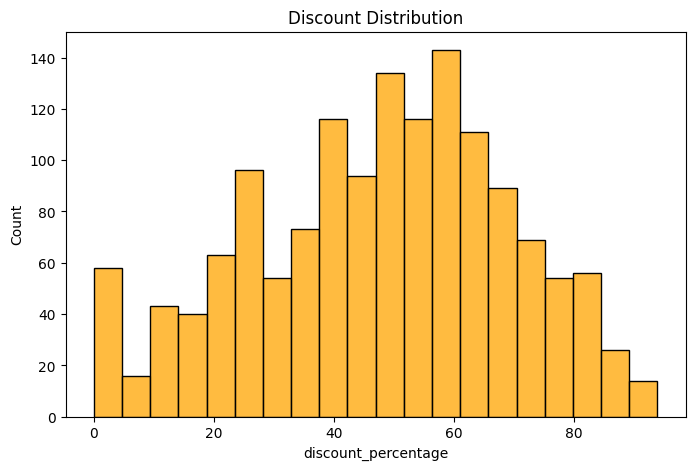

In [11]:
# Discount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['discount_percentage'], bins=20, color='orange')
plt.title("Discount Distribution")
plt.show()

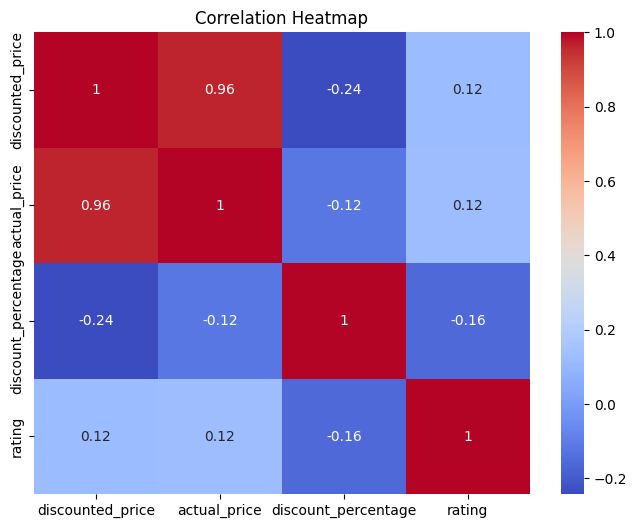

In [12]:
# correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['discounted_price','actual_price','discount_percentage','rating']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

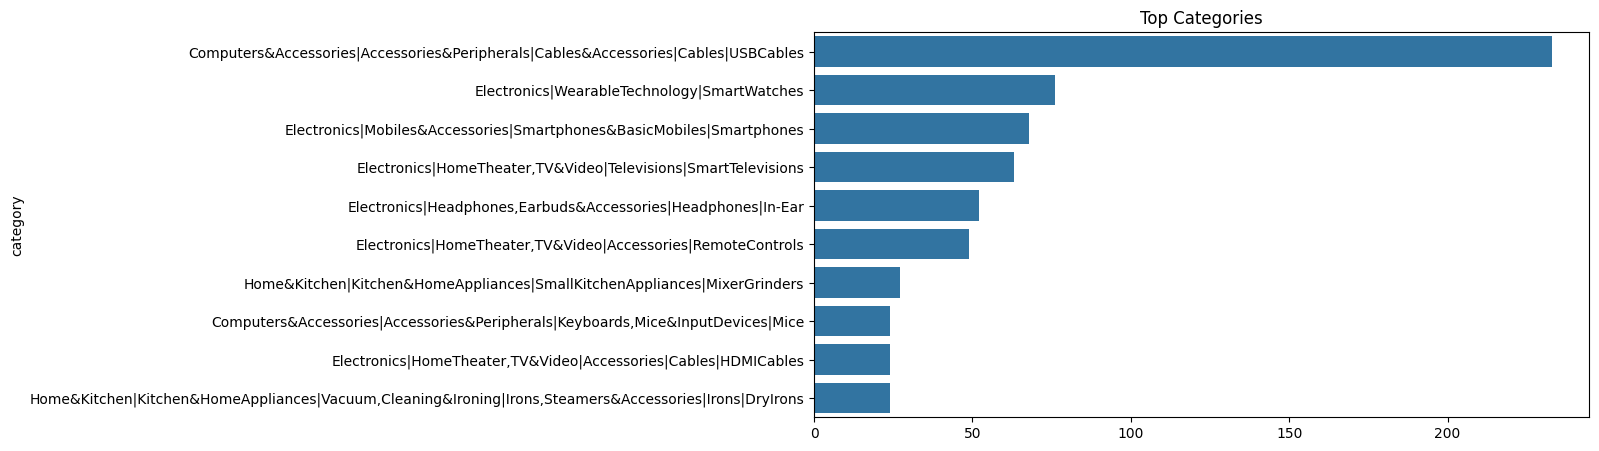

In [13]:
# top categories
top_categories = df['category'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title("Top Categories")
plt.show()

In [14]:
# most reviewed products
df[['product_name','rating_count']].sort_values(by='rating_count', ascending=False).head(10)

,product_name,rating_count
1279,Eureka Forbes car Vac 100 Watts Powerful Sucti...,992
750,Eveready Red 1012 AAA Batteries - Pack of 10,989
977,Sennheiser CX 80S in-Ear Wired Headphones with...,"98,250"
1059,Pigeon 1.5 litre Hot Kettle and Stainless Stee...,976
151,Zoul USB Type C Fast Charging 3A Nylon Braided...,974
32,Zoul USB C 60W Fast Charging 3A 6ft/2M Long Ty...,974
823,Zoul USB C 60W Fast Charging 3A 6ft/2M Long Ty...,974
536,boAt Rockerz 400 Bluetooth On Ear Headphones W...,"97,175"
918,boAt Rockerz 400 Bluetooth On Ear Headphones W...,"97,174"
1165,Kitchenwell 18Pc Plastic Food Snack Bag Pouch ...,97


Insights:
1. Most products have rating between 4.0 to 4.5
2. Electronics category dominates
3. High discount does not always mean high rating
4. Some products have extreme discount values

Conclusion:
This EDA analyzed Amazon product data including ratings, prices, discounts and categories.
We found key trends in pricing, customer ratings and product popularity.